# Beam Quality Cut


In [39]:
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [40]:
from os import path, makedirs
from datetime import datetime
from functools import partial

import numpy as np
import pandas as pd

import sys
# sys.path.append('../../../')
sys.path.append('/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana') # absolute path for running on EAF
from pyanalib.split_df_helpers import *
from analysis_village.numucc_1p0pi.variable_configs import VariableConfig
from analysis_village.numucc_1p0pi.utils import *
from analysis_village.numucc_1p0pi.files_config import *
plt.style.use("presentation.mplstyle")



In [41]:
save_fig = True

today_str = datetime.now().strftime("%Y%m%d")
today_str = "final"
save_fig_dir = path.join(save_fig_base_dir, "beam_quality"+"_"+today_str)

if save_fig:
    if not path.exists(save_fig_dir):
        makedirs(save_fig_dir)
    print("saving plots in ", save_fig_dir)


saving plots in  /exp/sbnd/data/users/munjung/plots/numucc1p0pi/beam_quality_final


In [42]:
from pyanalib.split_df_helpers_new import *

df_dir = "/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_16_230705__sel_mup-data-1e20/merged_perTPC"

df_data = dfs_from_dir(search_dir=df_dir, 
                       filename_str="sel_mup-data", 
                       keys2load=['hdr', 'evt', 'bnbpot', 'trigger'],
                       n_max_concat=999)


Found 2 files to process
Files to process: ['/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_16_230705__sel_mup-data-1e20/merged_perTPC/2026_05_16_230705__sel_mup-data-1e20_merged_0000.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_16_230705__sel_mup-data-1e20/merged_perTPC/2026_05_16_230705__sel_mup-data-1e20_merged_0001.df']


100%|██████████| 2/2 [00:48<00:00, 24.30s/it]


In [43]:
data_evt_df_ = df_data['evt']
pot_df = df_data['bnbpot']
data_hdr_df_ = df_data['hdr']
trigger_df = df_data['trigger']
data_hdr_df_ = data_hdr_df_.join(trigger_df)


In [44]:
np.isnan(data_hdr_df_.global_trigger_time).sum()
np.isnan(data_hdr_df_.beam_gate_time_abs).sum()


np.int64(0)

In [45]:
# split data into 15 time-ordered chunks

n_time_splits = 15
chunk_idx = 0

data_evt_df_["mc", "iscc"] = 999

_sorted = data_hdr_df_.sort_values(["run", "evt"], kind="mergesort")
data_hdr_df_splits = [
    _sorted.iloc[idx]
    for idx in np.array_split(np.arange(len(_sorted)), n_time_splits)
]
for i in range(n_time_splits):
    data_hdr_df = data_hdr_df_splits[i]

data_hdr_df = data_hdr_df_splits[chunk_idx]
evt_idxs = data_evt_df_.index
common_idxs = data_evt_df_.reset_index(level=[2]).index.intersection(data_hdr_df.index)
data_evt_df = data_evt_df_.reset_index(level=[2]).loc[common_idxs].reset_index().set_index(["__ntuple", "entry", "rec.slc..index"])


/tmp/ipykernel_1799478/1859459668.py:6: PerformanceWarning: indexing past lexsort depth may impact performance.
  data_evt_df_["mc", "iscc"] = 999


In [46]:
# --- Task 1: Time window per chunk ---
# global_trigger_time is in nanoseconds
chunk_summary = []
for i, chunk_df in enumerate(data_hdr_df_splits):
    t_min = chunk_df['global_trigger_time'].min()
    t_max = chunk_df['global_trigger_time'].max()
    chunk_summary.append({
        'Chunk': i,
        'Events': len(chunk_df),
        'Start Time (UTC)': pd.Timestamp(t_min, unit='ns', tz='UTC').strftime('%Y-%m-%d %H:%M:%S %Z'),
        'End Time (UTC)': pd.Timestamp(t_max, unit='ns', tz='UTC').strftime('%Y-%m-%d %H:%M:%S %Z'),
        'Duration (min)': round((t_max - t_min) / 60e9, 1),
    })

chunk_time_df = pd.DataFrame(chunk_summary).set_index('Chunk')
chunk_time_df


,Events,Start Time (UTC),End Time (UTC),Duration (min)
Chunk,,,,
0,118262,2025-02-13 21:11:24 UTC,2025-02-17 10:31:38 UTC,5120.2
1,118262,2025-02-17 10:31:40 UTC,2025-02-21 00:22:20 UTC,5150.7
2,118262,2025-02-21 00:22:23 UTC,2025-02-24 05:07:56 UTC,4605.5
3,118262,2025-02-24 05:07:59 UTC,2025-02-27 12:00:50 UTC,4732.9
4,118262,2025-02-27 12:00:50 UTC,2025-03-02 16:24:13 UTC,4583.4
5,118262,2025-03-02 16:24:16 UTC,2025-03-06 03:21:16 UTC,4977.0
6,118261,2025-03-06 03:21:18 UTC,2025-03-11 11:15:00 UTC,7673.7
7,118261,2025-03-11 11:15:03 UTC,2025-03-15 11:35:10 UTC,5780.1
8,118261,2025-03-15 11:35:22 UTC,2025-03-19 10:54:41 UTC,5719.3


In [47]:
# --- Task 2: Match each triggered event to its beam spill ---
# Strategy: for each trigger, find the latest beam spill (within the same ntuple)
# whose start time is <= trigger_time.  Uses numpy searchsorted per ntuple so
# there are no merge_asof edge-cases (NaN keys, absent ntuples, etc.).
#
# If a trigger's ntuple has no entries in pot_df at all, fall back to the
# nearest spill across *all* ntuples.
#
# Assignment is done positionally (via .values) to avoid pandas index-alignment
# NaN issues that arise when data_hdr_df_ has duplicate (__ntuple, entry) pairs.

pot_reset = pot_df.reset_index()
pot_reset['spill_time'] = pot_reset['spill_time_sec'] + pot_reset['spill_time_nsec'] * 1e-9

hdr_reset = data_hdr_df_.reset_index()[['__ntuple', 'entry', 'evt', 'global_trigger_time']]
hdr_reset['trigger_time_s'] = hdr_reset['global_trigger_time'] * 1e-9  # ns -> s
hdr_reset['_orig_idx'] = np.arange(len(hdr_reset))  # preserve row order for positional assignment

beam_cols = ['TOR875', 'TOR860', 'FOM', 'THCURR', 'spill_time']

# Build a per-ntuple lookup table (sorted by spill_time for searchsorted)
pot_by_ntuple = {
    ntuple: grp.sort_values('spill_time').reset_index(drop=True)
    for ntuple, grp in pot_reset.groupby('__ntuple')
}
# Global fallback (for ntuples entirely absent from pot_df)
all_spills = pot_reset.sort_values('spill_time').reset_index(drop=True)

results = []
n_global_fallback = 0
fallback_rows = []  # collect fallback events for printing

for ntuple, hdr_grp in hdr_reset.groupby('__ntuple'):
    spills = pot_by_ntuple.get(ntuple)
    if spills is None:
        # Ntuple absent from pot_df: use globally nearest spill
        spills = all_spills
        n_global_fallback += len(hdr_grp)
        fallback_rows.append(hdr_grp[['__ntuple', 'entry', 'evt', 'trigger_time_s']])

    times = spills['spill_time'].values
    trigger_times = hdr_grp['trigger_time_s'].values

    # searchsorted gives the insertion point; -1 gives the index of the
    # latest spill whose start is at or before the trigger time.
    # clip ensures we never go out of bounds (handles triggers before the
    # first spill or after the last spill).
    idx = np.searchsorted(times, trigger_times, side='right') - 1
    idx = np.clip(idx, 0, len(spills) - 1)

    matched_spills = spills.iloc[idx][beam_cols].reset_index(drop=True)
    result = hdr_grp[['_orig_idx']].reset_index(drop=True)
    result = pd.concat([result, matched_spills], axis=1)
    results.append(result)

# Sort back to original row order and assign positionally — avoids all
# index-alignment issues (e.g. duplicate (__ntuple, entry) pairs).
matched_ordered = pd.concat(results, ignore_index=True).sort_values('_orig_idx')

for col in beam_cols:
    data_hdr_df_[col] = matched_ordered[col].values

n_matched = data_hdr_df_['TOR875'].notna().sum()
n_total   = len(data_hdr_df_)

if n_global_fallback:
    print(f"  {n_global_fallback} event(s) had no pot_df entry for their ntuple "
          f"— matched to nearest global spill instead.")
    fallback_df = pd.concat(fallback_rows, ignore_index=True)
    print(fallback_df.to_string(index=False))
print(f"Matched {n_matched} / {n_total} events to a beam spill.")

# --- Diagnostic: print any events that are still unmatched ---
failures = data_hdr_df_[data_hdr_df_['TOR875'].isna()]
if len(failures) > 0:
    print(f"\n=== {len(failures)} UNMATCHED EVENT(S) ===")
    print(failures.reset_index()[['__ntuple', 'entry', 'evt', 'global_trigger_time']].to_string())
    print(f"\ndata_hdr_df_.index.is_unique : {data_hdr_df_.index.is_unique}")
    print(f"matched_ordered has {len(matched_ordered)} rows for {n_total} events")
else:
    print("All events matched successfully.")

data_hdr_df_[['evt', 'global_trigger_time', 'TOR875', 'TOR860', 'FOM', 'THCURR', 'spill_time']].head(20)


  2 event(s) had no pot_df entry for their ntuple — matched to nearest global spill instead.
 __ntuple  entry  evt  trigger_time_s
     9724      0   46    1.741386e+09
    10619      0   31    1.744212e+09
Matched 1773921 / 1773921 events to a beam spill.
All events matched successfully.


evt  global_trigger_time        TOR875        TOR860  \
__ntuple entry                                                           
6        0      54154  1742610765958599280  5.026960e+12  5.009113e+12   
         1      54242  1742610793239450960  4.992409e+12  4.972572e+12   
         2      54484  1742610864142079880  5.007970e+12  4.981042e+12   
         3      54528  1742610876278494700  4.993069e+12  4.984761e+12   
         4      54814  1742610963053976220  4.996186e+12  4.983090e+12   
         5      54968  1742611007340534360  5.047129e+12  5.016546e+12   
         6      54990  1742611014342634160  5.003764e+12  4.965172e+12   
         7      55122  1742611052090798540  4.989512e+12  4.981904e+12   
         8      55166  1742611064227796580  5.022298e+12  4.980251e+12   
         9      55342  1742611117116660440  5.012710e+12  4.980489e+12   
         10     55452  1742611150265266560  5.018753e+12  5.019020e+12   
         11     55606  1742611194146530060  4.960442e+12  4.948892e+12   
         12     55650  1742611205413728740  4.990433e+12  4.939008e+12   
         13     55672  1742611211147140860  4.978537e+12  4.969506e+12   
         14     55892  1742611275165337160  5.025606e+12  4.983724e+12   
         15     56112  1742611341331561000  4.954052e+12  4.955763e+12   
         16     56640  1742611491376151360  4.984906e+12  4.970233e+12   
         17     56772  1742611527391748140  4.915268e+12  4.937575e+12   
         18     56838  1742611547268978180  4.961985e+12  4.964995e+12   
         19     56882  1742611559475093120  4.965505e+12  4.952181e+12   

                     FOM      THCURR    spill_time  
__ntuple entry                                      
6        0      0.999840  172.851562  1.742611e+09  
         1      0.999753  173.789062  1.742611e+09  
         2      4.000000  173.769531  1.742611e+09  
         3      0.999830  173.828125  1.742611e+09  
         4      0.999805  173.056641  1.742611e+09  
         5      0.999702  173.808594  1.742611e+09  
         6      0.999816  173.847656  1.742611e+09  
         7      0.999797  172.841797  1.742611e+09  
         8      0.999788  173.750000  1.742611e+09  
         9      0.999741  172.871094  1.742611e+09  
         10     0.999704  173.828125  1.742611e+09  
         11     0.999770  173.046875  1.742611e+09  
         12     0.999917  173.828125  1.742611e+09  
         13     0.999803  172.861328  1.742611e+09  
         14     0.999815  172.949219  1.742611e+09  
         15     0.999893  173.847656  1.742611e+09  
         16     0.999895  173.828125  1.742611e+09  
         17     0.999896  173.798828  1.742612e+09  
         18     0.999844  173.144531  1.742612e+09  
         19     0.999690  173.769531  1.742612e+09

In [48]:
# pot_df.loc[18226]
# data_hdr_df_.loc[18226]


In [49]:
# 645084      18226   46    1.741386e+09
# 1617671     19874   31    1.744212e+09


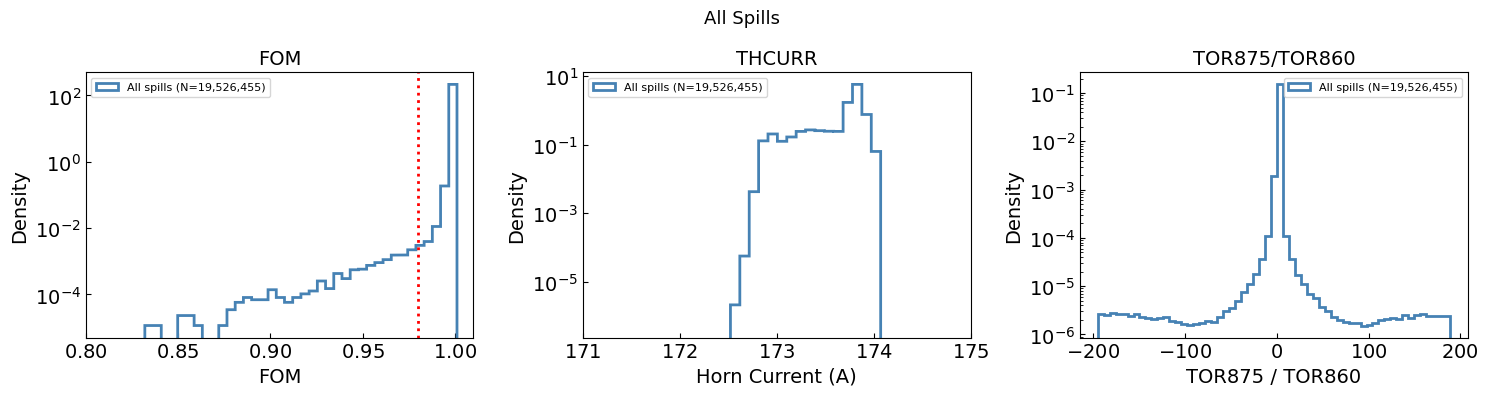

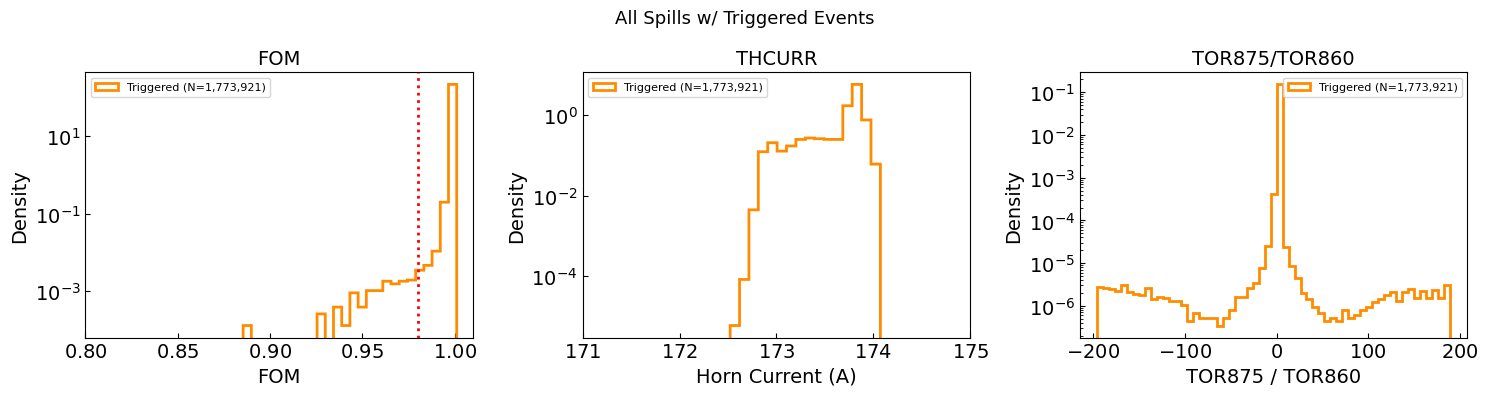

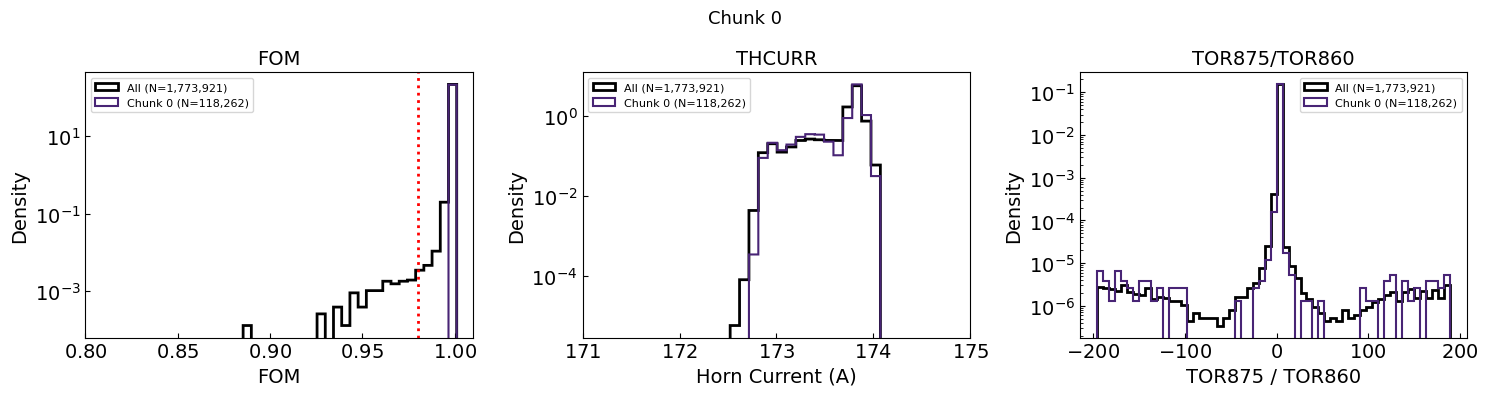

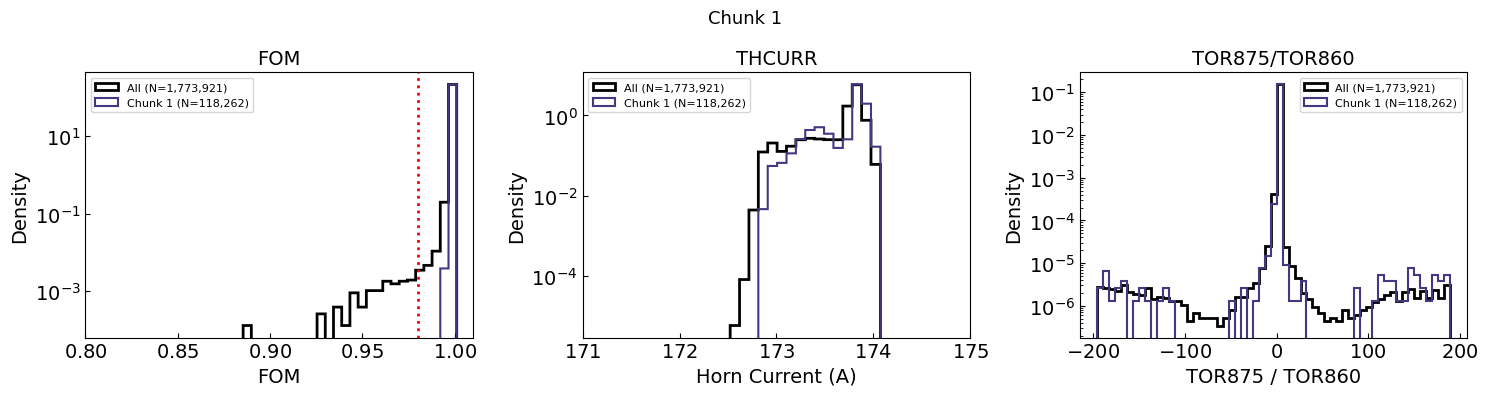

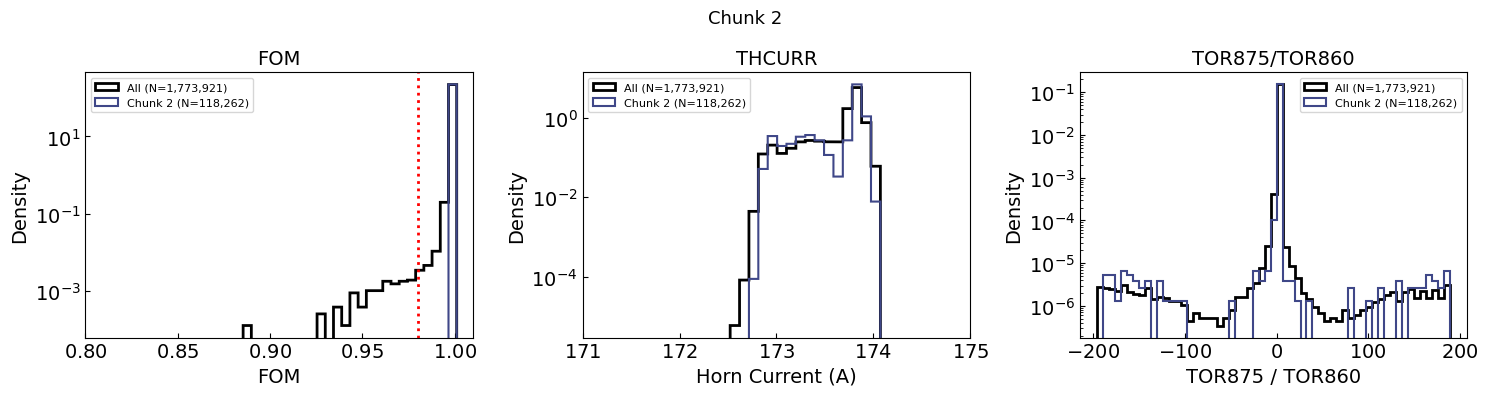

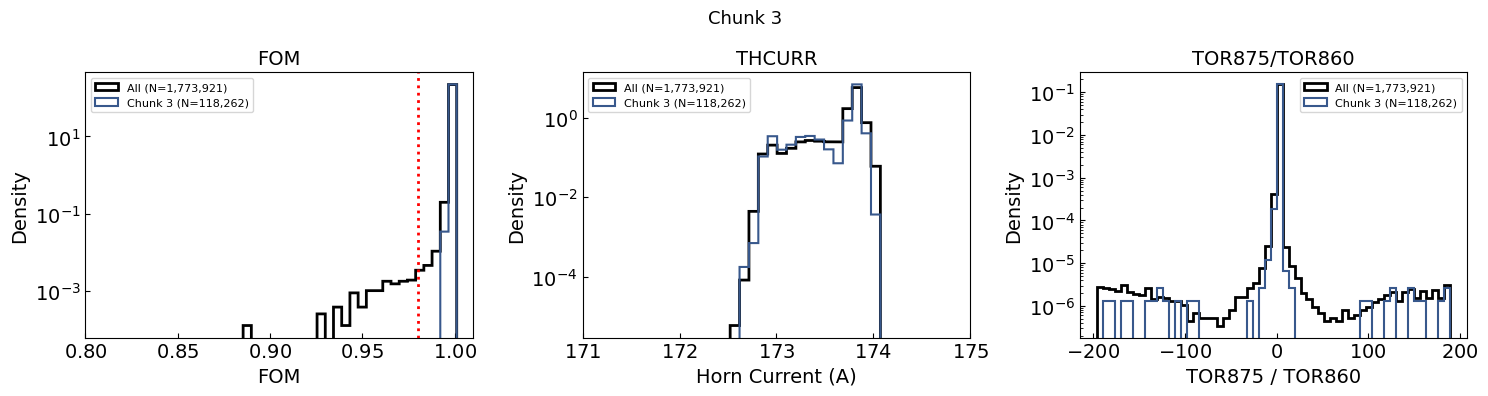

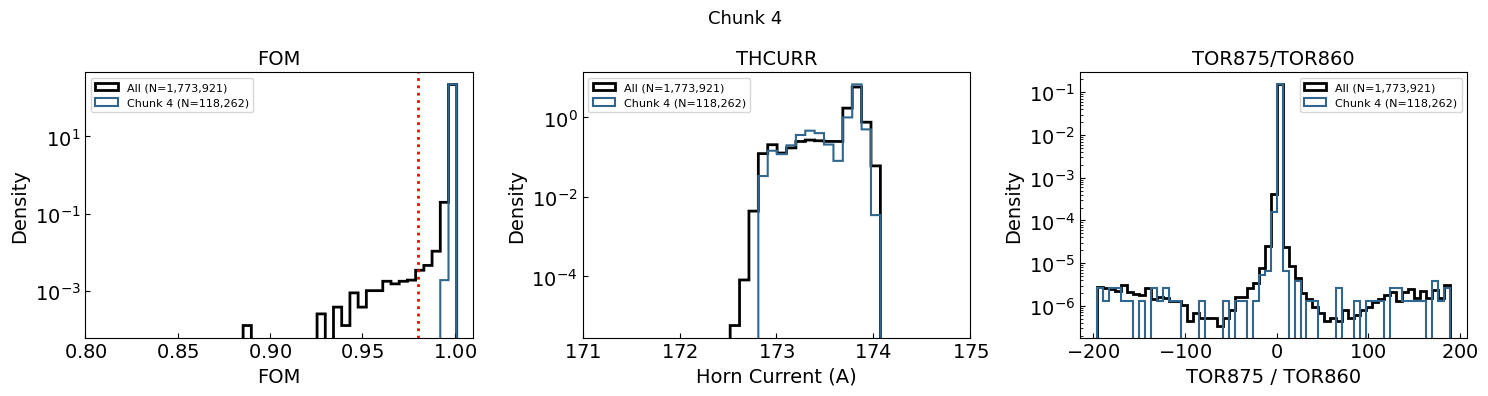

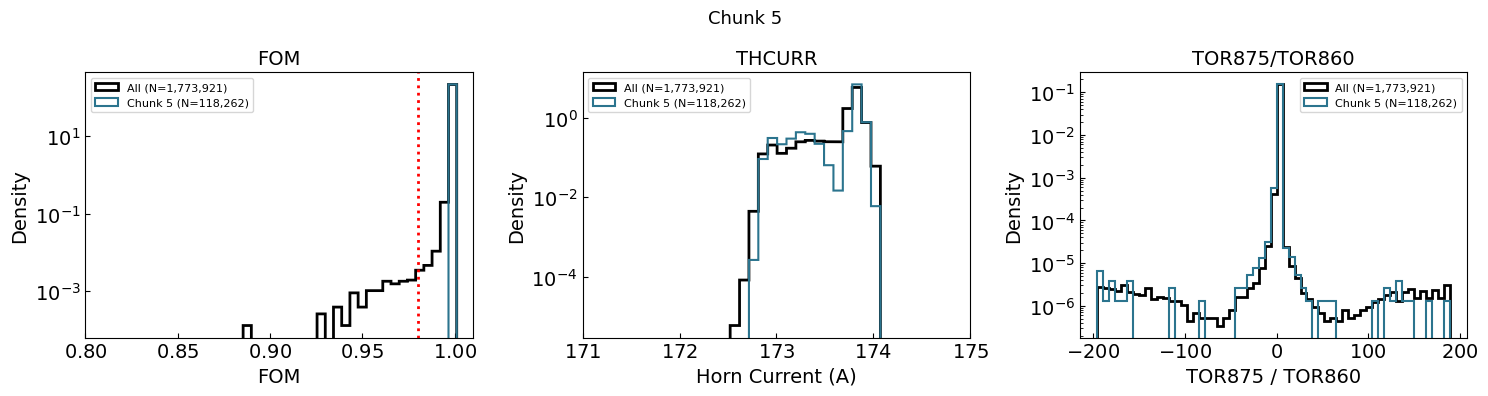

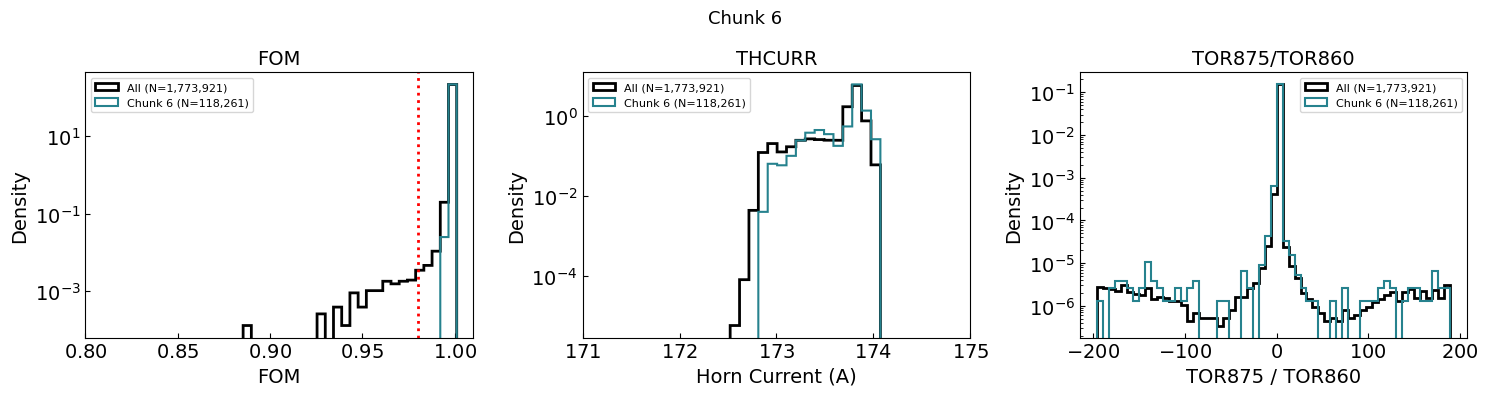

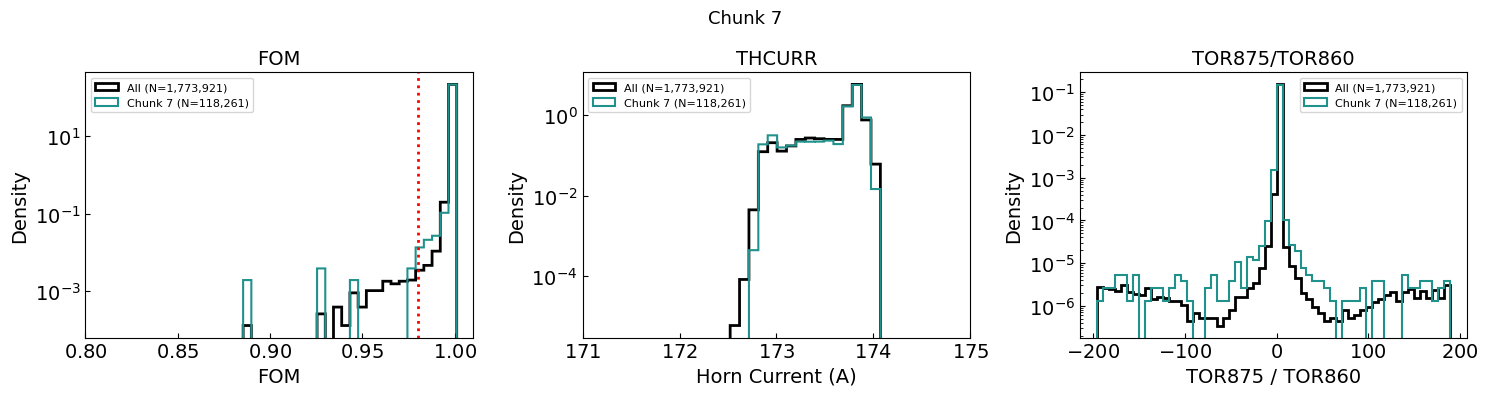

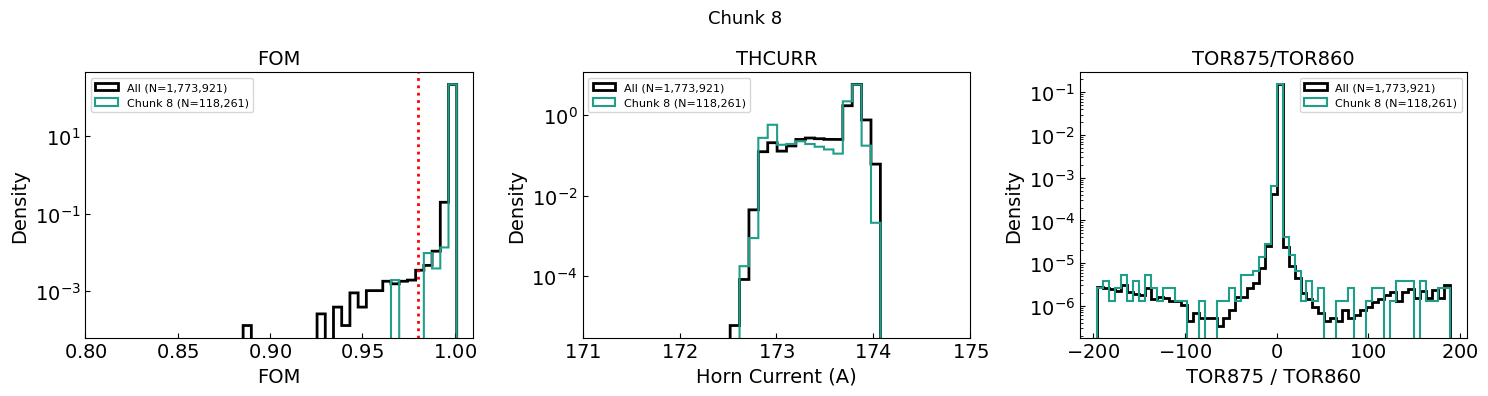

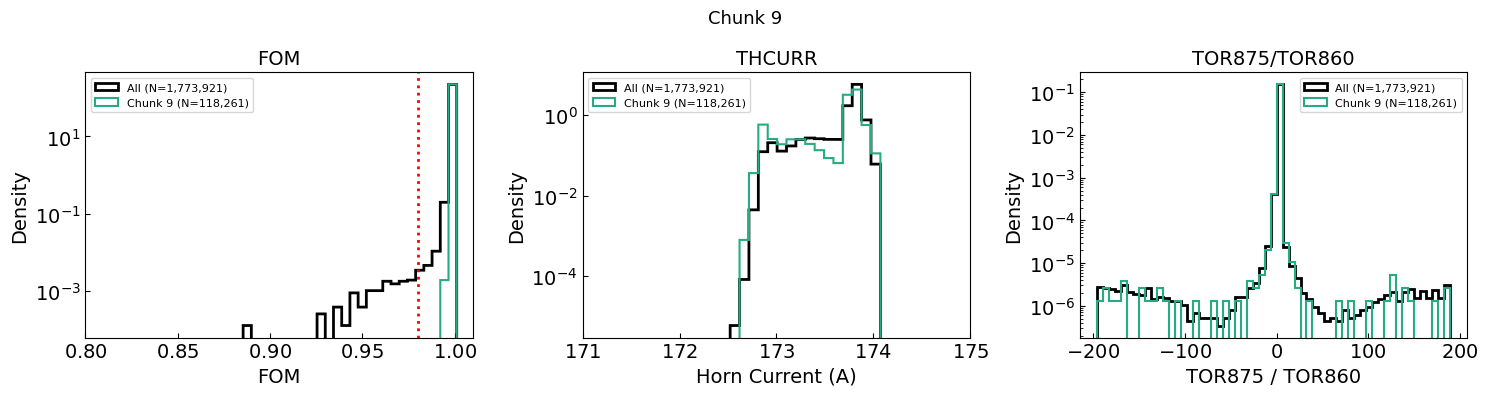

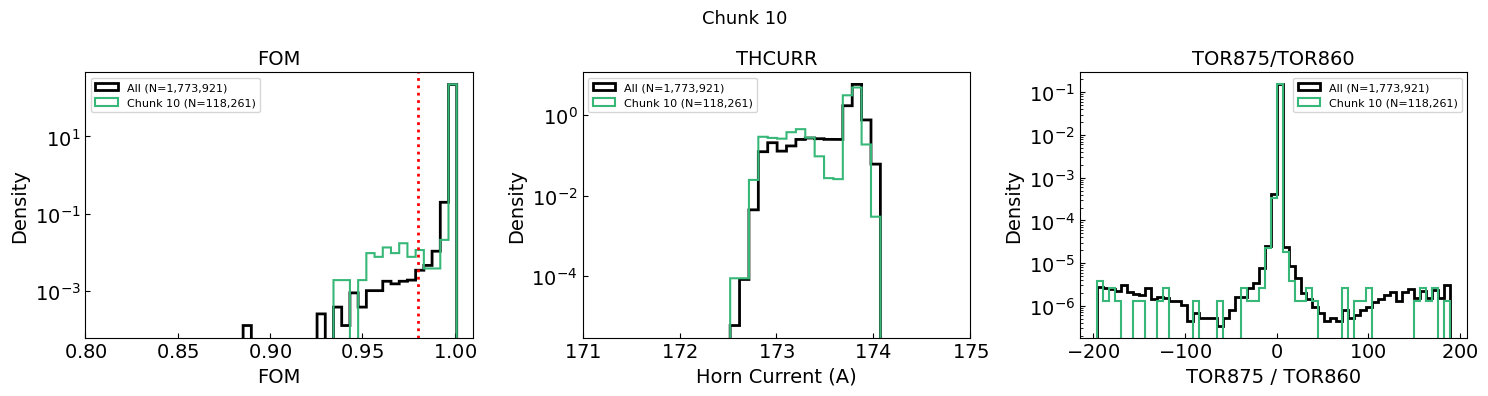

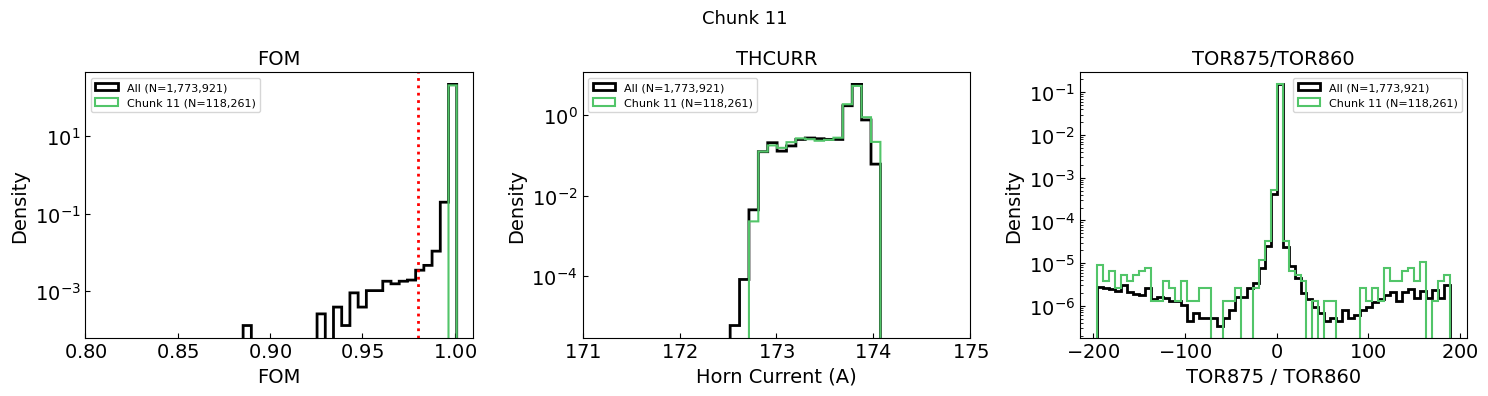

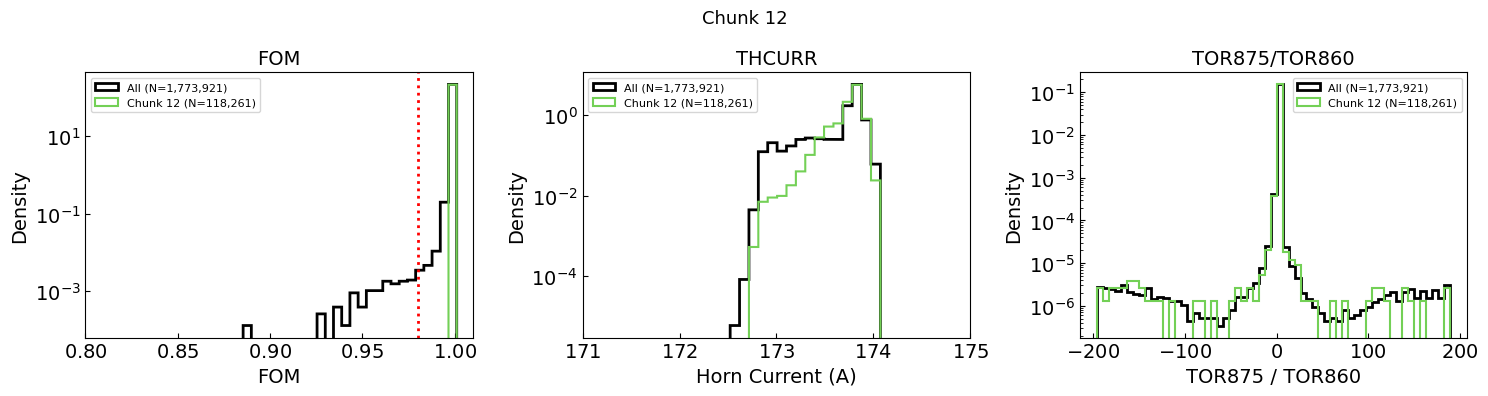

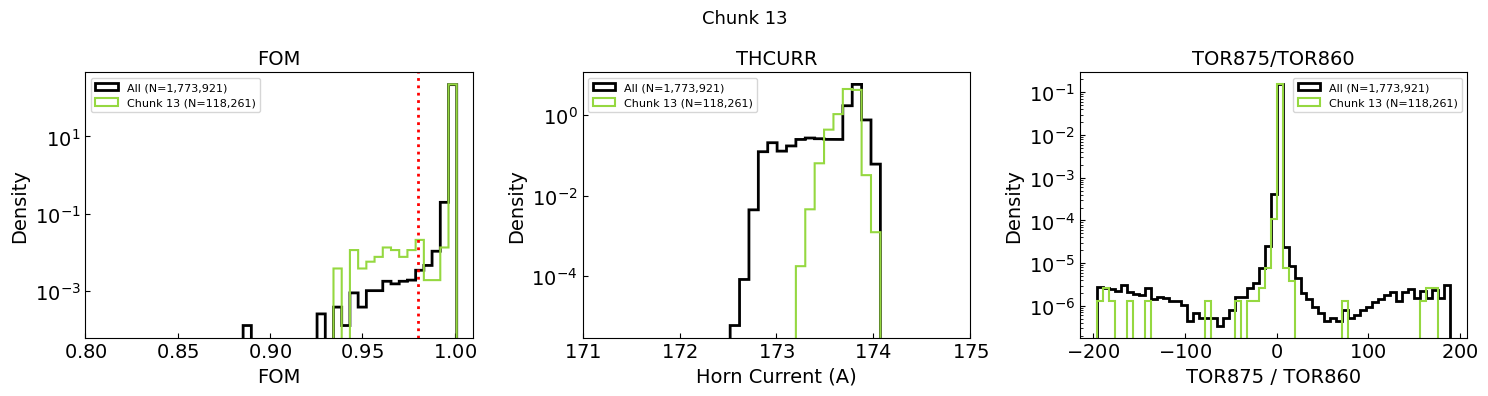

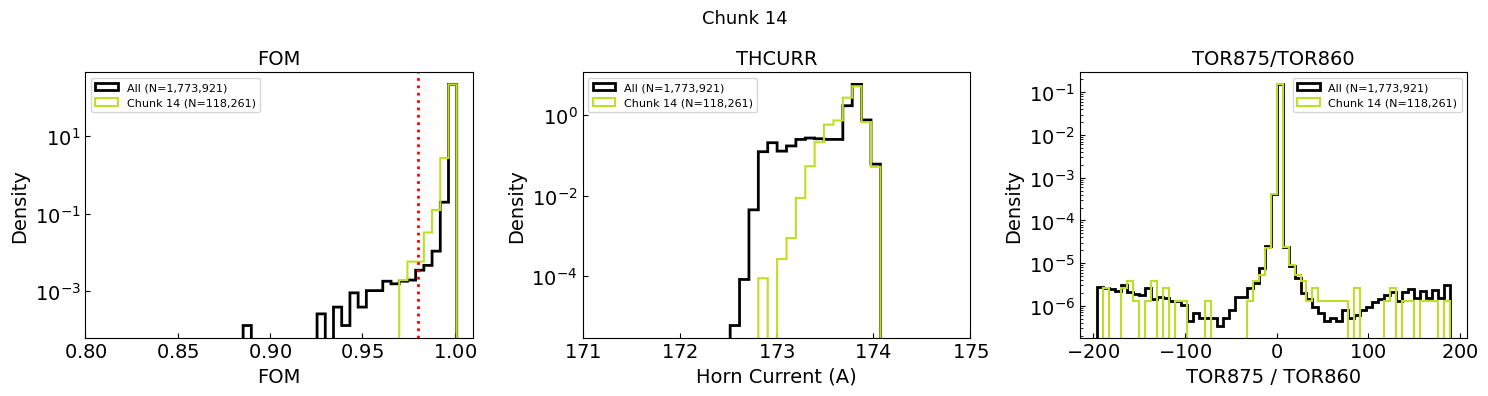

In [50]:
# --- Beam quality metrics ---
# Re-split data_hdr_df_ (now includes matched beam columns) into time chunks
_sorted_beam = data_hdr_df_.sort_values(["run", "evt"], kind="mergesort")
hdr_splits_beam = [
    _sorted_beam.iloc[idx]
    for idx in np.array_split(np.arange(len(_sorted_beam)), n_time_splits)
]

pot_reset = pot_df.reset_index().copy()
pot_reset['TOR_ratio'] = pot_reset['TOR875'] / pot_reset['TOR860']

hdr_all = data_hdr_df_[['TOR875', 'TOR860', 'FOM', 'THCURR']].dropna().copy()
hdr_all['TOR_ratio'] = hdr_all['TOR875'] / hdr_all['TOR860']

metrics = [
    ('FOM',       r'FOM',           r'FOM'),
    ('THCURR',    r'THCURR',        r'Horn Current (A)'),
    ('TOR_ratio', r'TOR875/TOR860', r'TOR875 / TOR860'),
]

def get_vals(df, col):
    if col == 'TOR_ratio':
        return (df['TOR875'] / df['TOR860']).replace([np.inf, -np.inf], np.nan).dropna()
    return df[col].replace([np.inf, -np.inf], np.nan).dropna()

xlim_dict = {
    'FOM':       (0.8,  1.01),
    'THCURR':    (171,  175),
    'TOR_ratio': None,          # no restriction — use full range
}

def make_beam_fig(title, datasets, bins_dict, save_suffix=None):
    """datasets: list of (label, color, linewidth, vals_dict {col: series})"""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, (col, label, xlabel) in zip(axes, metrics):
        bins = bins_dict[col]
        for ds_label, color, lw, vals_dict in datasets:
            vals = vals_dict[col]
            if len(vals) == 0:
                continue
            ax.hist(vals, bins=bins, density=True, histtype='step',
                    linewidth=lw, color=color, label=f'{ds_label} (N={len(vals):,})')
        ax.set_yscale('log')
        ax.set_xlabel(xlabel)
        ax.set_ylabel('Density')
        ax.set_title(label)
        ax.legend(fontsize=8)
        if col == 'FOM':
            ax.axvline(0.98, color='red', linestyle=':', linewidth=2)
        if xlim_dict.get(col) is not None:
            ax.set_xlim(xlim_dict[col])
    fig.suptitle(title, fontsize=13)
    fig.tight_layout()
    if save_fig and save_suffix:
        fig.savefig(path.join(save_fig_dir, f"{today_str}_beam_{save_suffix}.png"), dpi=300, bbox_inches='tight')
    plt.show()

# Build shared bins from the global all-spills distribution
# Use 15x more bins for FOM and THCURR (zoomed metrics).
bins_dict = {}
base_nbins = 60
nbins_dict = {
    'FOM': base_nbins * 15,
    'THCURR': base_nbins * 30,
    'TOR_ratio': base_nbins,
}
for col, _, _ in metrics:
    vals = get_vals(pot_reset, col)
    nbins = nbins_dict.get(col, base_nbins)
    bins_dict[col] = np.linspace(vals.quantile(0.001), vals.quantile(0.999), nbins)

# --- Figure 1: All spills (pot_df) ---
all_spills_data = {col: get_vals(pot_reset, col) for col, _, _ in metrics}
make_beam_fig(
    title='All Spills ',
    datasets=[('All spills', 'steelblue', 2, all_spills_data)],
    bins_dict=bins_dict,
    save_suffix='all_spills',
)

# --- Figure 2: All triggered spills (data_hdr_df_) ---
triggered_data = {col: get_vals(hdr_all, col) for col, _, _ in metrics}
make_beam_fig(
    title='All Spills w/ Triggered Events',
    datasets=[('Triggered', 'darkorange', 2, triggered_data)],
    bins_dict=bins_dict,
    save_suffix='all_triggered',
)

# --- Figure per chunk: all triggered spills vs. chunk triggered ---
chunk_colors = plt.cm.viridis(np.linspace(0.1, 0.9, n_time_splits))
for i, chunk_df in enumerate(hdr_splits_beam):
    chunk_data = {col: get_vals(chunk_df, col) for col, _, _ in metrics}
    make_beam_fig(
        title=f'Chunk {i}',
        datasets=[
            ('All', 'black',         2,   triggered_data),
            (f'Chunk {i}',    chunk_colors[i], 1.5, chunk_data)
        ],
        bins_dict=bins_dict,
        save_suffix=f'chunk_{i:02d}',
    )


NameError: name 'add_sbnd_internal' is not defined

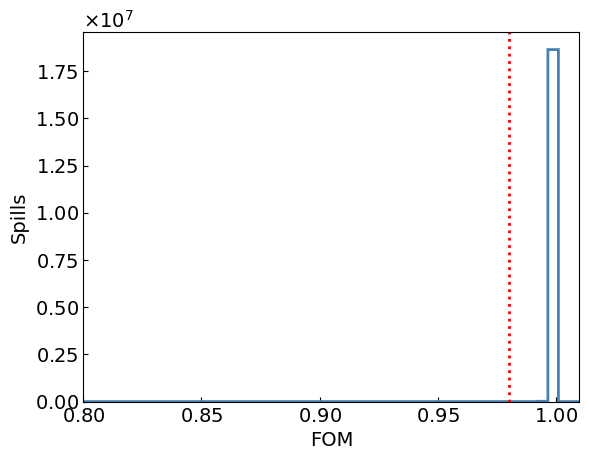

In [72]:
# --- Spill count histograms (one figure per metric) ---
FOM_CUT_SPILLS = 0.98
pot_fom = pot_reset["FOM"]
pot_fom_failure = (pot_fom == 0) | (pot_fom == 4)
pot_fom_bad = (pot_fom < FOM_CUT_SPILLS) & (pot_fom > 0)

FOM_OVERLAY_COLORS = {
    "invalid": "#FF3366",   # bright pink-red
    "bad": "#33EEFF",       # bright cyan
}


def plot_spill_counts(vals, bins, xlabel, col, save_suffix=None, overlays=None, density=False):
    fig, ax = plt.subplots()
    ax.hist(
        vals,
        bins=bins,
        histtype="step",
        linewidth=2,
        color="steelblue",
        density=density,
        label="All spills",
    )
    if overlays:
        for overlay_vals, color, label in overlays:
            if len(overlay_vals) == 0:
                continue
            ax.hist(
                overlay_vals,
                bins=bins,
                histtype="step",
                linewidth=2,
                color=color,
                density=density,
                label=label,
            )
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Spills (Area Noramlized)" if density else "Spills")
    if col == "FOM":
        ax.axvline(FOM_CUT_SPILLS, color="red", linestyle=":", linewidth=2)
    if xlim_dict.get(col) is not None:
        ax.set_xlim(xlim_dict[col])
    if overlays:
        ax.legend(fontsize=10)
    fig.tight_layout()
    ax.set_yscale("log")
    if save_fig and save_suffix:
        fig.savefig(
            path.join(save_fig_dir, f"{today_str}_beam_{save_suffix}_counts.png"),
            dpi=300,
            bbox_inches="tight",
        )
    plt.show()


for col, _label, xlabel in metrics:
    vals = get_vals(pot_reset, col)
    overlays = None
    use_density = col in ("THCURR", "TOR_ratio")
    if use_density:
        overlays = [
            (
                get_vals(pot_reset.loc[pot_fom_failure], col),
                FOM_OVERLAY_COLORS["invalid"],
                "Invalid FOM (0 | 4)",
            ),
            (
                get_vals(pot_reset.loc[pot_fom_bad], col),
                FOM_OVERLAY_COLORS["bad"],
                f"Bad FOM (0 < FOM < {FOM_CUT_SPILLS})",
            ),
        ]
    plot_spill_counts(
        vals,
        bins_dict[col],
        xlabel,
        col,
        save_suffix=f"all_spills_{col}",
        overlays=overlays,
        density=use_density,
    )


In [71]:
save_fig_dir


'/exp/sbnd/data/users/munjung/plots/numucc1p0pi/beam_quality_final'

In [52]:
# --- Extended time-window table with beam quality failure statistics (per chunk) ---
# Uses hdr_splits_beam from the plotting cell (matched FOM per triggered event)
beam_stats = []
for i, chunk_df in enumerate(hdr_splits_beam):
    fom = chunk_df['FOM'].dropna()
    n_total = len(fom)
    n_failures = int((fom == 0).sum() + (fom == 4).sum())   # FOM == 0 or FOM == 4
    n_bad      = int(((fom < 0.98) & (fom > 0)).sum())                     # FOM < 0.98 (includes failures)
    beam_stats.append({
        'Chunk': i,
        'Failures % (FOM=0|4)':   round(100 * n_failures / n_total, 2) if n_total > 0 else float('nan'),
        'Bad Spills % (FOM<0.98)': round(100 * n_bad      / n_total, 2) if n_total > 0 else float('nan'),
    })

beam_stats_df = pd.DataFrame(beam_stats).set_index('Chunk')
chunk_time_extended_df = chunk_time_df.drop(columns=['Duration (min)']).join(beam_stats_df)
display(chunk_time_extended_df)

# --- LaTeX table output ---
latex_df = chunk_time_extended_df.copy()
latex_df.index.name = 'Chunk'
latex_str = latex_df.to_latex(
    float_format='%.2f',
    caption='Time window and beam quality summary per data chunk.',
    label='tab:beam_quality_chunks',
    column_format='c' * 6,
)
print(latex_str)


,Events,Start Time (UTC),End Time (UTC),Failures % (FOM=0|4),Bad Spills % (FOM<0.98)
Chunk,,,,,
0,118262,2025-02-13 21:11:24 UTC,2025-02-17 10:31:38 UTC,4.00,0.00
1,118262,2025-02-17 10:31:40 UTC,2025-02-21 00:22:20 UTC,2.32,0.00
2,118262,2025-02-21 00:22:23 UTC,2025-02-24 05:07:56 UTC,1.15,0.00
3,118262,2025-02-24 05:07:59 UTC,2025-02-27 12:00:50 UTC,1.24,0.00
4,118262,2025-02-27 12:00:50 UTC,2025-03-02 16:24:13 UTC,1.04,0.00
5,118262,2025-03-02 16:24:16 UTC,2025-03-06 03:21:16 UTC,1.70,0.00
6,118261,2025-03-06 03:21:18 UTC,2025-03-11 11:15:00 UTC,1.62,0.00
7,118261,2025-03-11 11:15:03 UTC,2025-03-15 11:35:10 UTC,2.82,0.01
8,118261,2025-03-15 11:35:22 UTC,2025-03-19 10:54:41 UTC,1.68,0.00


\begin{table}
\caption{Time window and beam quality summary per data chunk.}
\label{tab:beam_quality_chunks}
\begin{tabular}{cccccc}
\toprule
 & Events & Start Time (UTC) & End Time (UTC) & Failures % (FOM=0|4) & Bad Spills % (FOM<0.98) \\
Chunk &  &  &  &  &  \\
\midrule
0 & 118262 & 2025-02-13 21:11:24 UTC & 2025-02-17 10:31:38 UTC & 4.00 & 0.00 \\
1 & 118262 & 2025-02-17 10:31:40 UTC & 2025-02-21 00:22:20 UTC & 2.32 & 0.00 \\
2 & 118262 & 2025-02-21 00:22:23 UTC & 2025-02-24 05:07:56 UTC & 1.15 & 0.00 \\
3 & 118262 & 2025-02-24 05:07:59 UTC & 2025-02-27 12:00:50 UTC & 1.24 & 0.00 \\
4 & 118262 & 2025-02-27 12:00:50 UTC & 2025-03-02 16:24:13 UTC & 1.04 & 0.00 \\
5 & 118262 & 2025-03-02 16:24:16 UTC & 2025-03-06 03:21:16 UTC & 1.70 & 0.00 \\
6 & 118261 & 2025-03-06 03:21:18 UTC & 2025-03-11 11:15:00 UTC & 1.62 & 0.00 \\
7 & 118261 & 2025-03-11 11:15:03 UTC & 2025-03-15 11:35:10 UTC & 2.82 & 0.01 \\
8 & 118261 & 2025-03-15 11:35:22 UTC & 2025-03-19 10:54:41 UTC & 1.68 & 0.00 \\
9 & 118

## Part 2: Run-level summary, quality cuts, and filtered outputs

Per-run time windows, flag runs shorter than 20 minutes, identify bad events
(bad beam spills or short runs), and write filtered `evt` tables plus a CSV event list.


3 / 72 runs shorter than 20 min


,Events,Start Time (UTC),End Time (UTC),Duration (min),Short run (<20 min)
run,,,,,
18250,20905,2025-02-13 21:11:24 UTC,2025-02-14 11:08:26 UTC,837.0,False
18253,74307,2025-02-14 18:01:45 UTC,2025-02-16 18:59:35 UTC,2937.8,False
18255,65551,2025-02-16 19:40:07 UTC,2025-02-18 13:54:19 UTC,2534.2,False
18259,32776,2025-02-18 23:18:06 UTC,2025-02-19 20:50:02 UTC,1291.9,False
18260,1410,2025-02-19 21:01:31 UTC,2025-02-19 22:06:34 UTC,65.0,False
...,...,...,...,...,...
18394,2977,2025-04-07 21:01:34 UTC,2025-04-07 22:52:43 UTC,111.1,False
18395,14814,2025-04-07 23:00:42 UTC,2025-04-08 09:07:06 UTC,606.4,False
18409,28578,2025-04-08 17:50:13 UTC,2025-04-09 12:25:38 UTC,1115.4,False


\begin{table}[htbp]
  \centering
  \caption{Run-level time window summary for the 1e20 data sample. Short runs ($<$20~min) are shown in red.}
  \label{tab:beam_quality_runs}
 egin{tabular}{r r l l r}
    \hline
    Run & Events & Start Time (UTC) & End Time (UTC) & Duration (min) \
    \hline
    18250 & 20905 & 2025-02-13 21:11:24 UTC & 2025-02-14 11:08:26 UTC & 837.0 \\
    18253 & 74307 & 2025-02-14 18:01:45 UTC & 2025-02-16 18:59:35 UTC & 2937.8 \\
    18255 & 65551 & 2025-02-16 19:40:07 UTC & 2025-02-18 13:54:19 UTC & 2534.2 \\
    18259 & 32776 & 2025-02-18 23:18:06 UTC & 2025-02-19 20:50:02 UTC & 1291.9 \\
    18260 & 1410 & 2025-02-19 21:01:31 UTC & 2025-02-19 22:06:34 UTC & 65.0 \\
    18261 & 79234 & 2025-02-19 22:16:00 UTC & 2025-02-22 00:08:58 UTC & 2993.0 \\
    18262 & 957 & 2025-02-22 00:31:15 UTC & 2025-02-22 01:07:25 UTC & 36.2 \\
    18263 & 842 & 2025-02-22 01:23:53 UTC & 2025-02-22 01:53:20 UTC & 29.5 \\
    18264 & 75228 & 2025-02-22 02:05:47 UTC & 2025-02-24 02:15

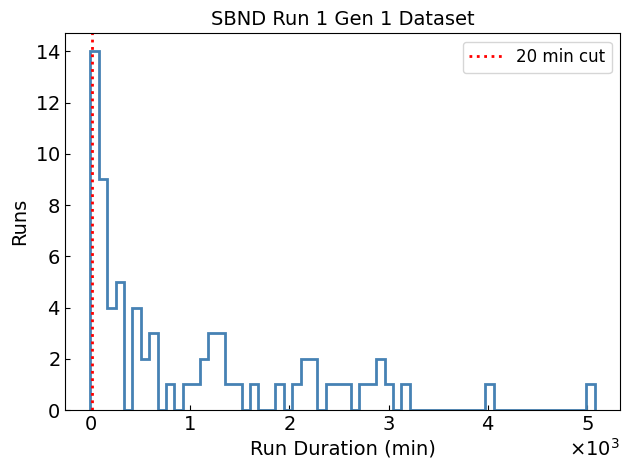

In [60]:
# --- Per-run time summary (not time chunks) ---
MIN_RUN_DURATION_MIN = 20.0

run_summary = []
for run, run_df in data_hdr_df_.groupby("run", sort=False):
    t_min = run_df["global_trigger_time"].min()
    t_max = run_df["global_trigger_time"].max()
    duration_min = (t_max - t_min) / 60e9
    run_summary.append({
        "run": int(run),
        "Events": len(run_df),
        "Start Time (UTC)": pd.Timestamp(t_min, unit="ns", tz="UTC").strftime("%Y-%m-%d %H:%M:%S %Z"),
        "End Time (UTC)": pd.Timestamp(t_max, unit="ns", tz="UTC").strftime("%Y-%m-%d %H:%M:%S %Z"),
        "Duration (min)": round(duration_min, 1),
        "t_min_ns": t_min,
    })

run_time_df = (
    pd.DataFrame(run_summary)
    .sort_values("t_min_ns", kind="mergesort")
    .drop(columns=["t_min_ns"])
    .reset_index(drop=True)
)
run_time_df["Short run (<20 min)"] = run_time_df["Duration (min)"] < MIN_RUN_DURATION_MIN
run_time_df = run_time_df.set_index("run")

short_runs = set(run_time_df.index[run_time_df["Short run (<20 min)"]])
print(f"{len(short_runs)} / {len(run_time_df)} runs shorter than {MIN_RUN_DURATION_MIN:.0f} min")
display(run_time_df)
# --- LaTeX table (short runs in red; requires \usepackage{xcolor}) ---
def run_time_df_to_latex(df, short_col="Short run (<20 min)"):
    """Return a copy-paste LaTeX table; short runs are colored red."""
    cols = [c for c in df.columns if c != short_col]
    col_fmt = "r r l l r"  # run, Events, Start, End, Duration

    def fmt_cell(val):
        return str(val).replace("_", r"\_")

    lines = [
        r"\begin{table}[htbp]",
        r"  \centering",
        r"  \caption{Run-level time window summary for the 1e20 data sample. Short runs ($<$20~min) are shown in red.}",
        r"  \label{tab:beam_quality_runs}",
        f"  \begin{{tabular}}{{{col_fmt}}}",
        r"    \hline",
        "    Run & Events & Start Time (UTC) & End Time (UTC) & Duration (min) \\",
        r"    \hline",
    ]

    for run, row in df.iterrows():
        vals = [
            fmt_cell(int(run)),
            fmt_cell(int(row["Events"])),
            fmt_cell(row["Start Time (UTC)"]),
            fmt_cell(row["End Time (UTC)"]),
            fmt_cell(row["Duration (min)"]),
        ]
        if bool(row[short_col]):
            vals = [rf"\textcolor{{red}}{{{v}}}" for v in vals]
        lines.append("    " + " & ".join(vals) + r" \\")

    lines += [
        r"    \hline",
        r"  \end{tabular}",
        r"\end{table}",
    ]
    return "\n".join(lines)

print(run_time_df_to_latex(run_time_df))

# --- Run duration histogram ---
fig, ax = plt.subplots()
durations = run_time_df["Duration (min)"].values
ax.hist(durations, bins=60, histtype="step", linewidth=2, color="steelblue")
ax.axvline(
    MIN_RUN_DURATION_MIN,
    color="red",
    linestyle=":",
    linewidth=2,
    label=f"{MIN_RUN_DURATION_MIN:.0f} min cut",
)
ax.set_xlabel("Run Duration (min)")
ax.set_ylabel("Runs")
ax.set_title("SBND Run 1 Gen 1 Dataset")
ax.legend(fontsize=12)
fig.tight_layout()
if save_fig:
    fig.savefig(
        path.join(save_fig_dir, f"{today_str}_run_duration.png"),
        dpi=300,
        bbox_inches="tight",
    )
plt.show()


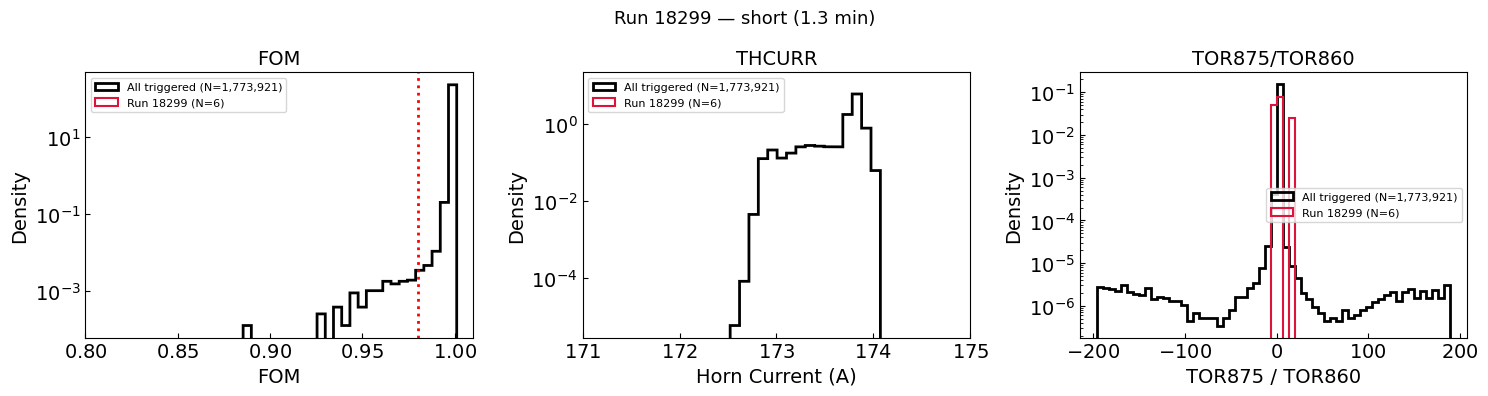

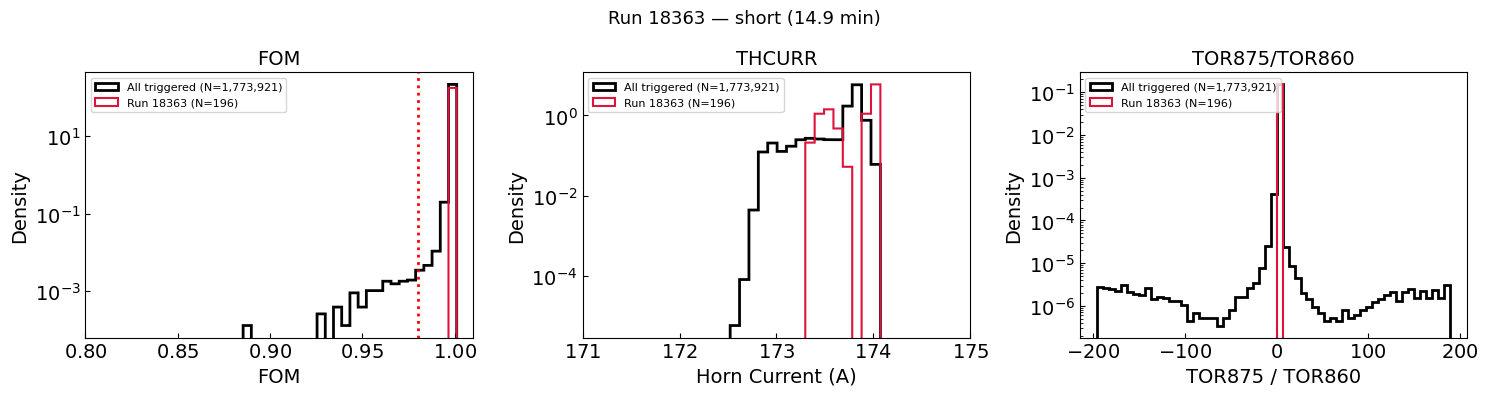

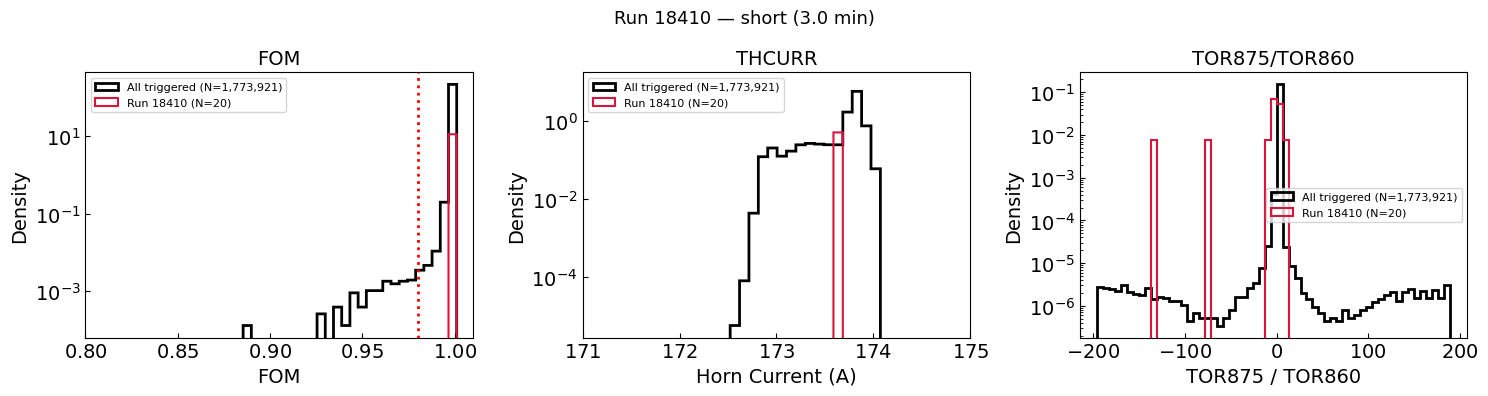

In [54]:
# --- Beam metric plots for short runs ---
if len(short_runs) == 0:
    print("No short runs to plot.")
else:
    for run in sorted(short_runs):
        run_df = data_hdr_df_[data_hdr_df_["run"] == run]
        duration = run_time_df.loc[run, "Duration (min)"]
        run_data = {col: get_vals(run_df, col) for col, _, _ in metrics}
        make_beam_fig(
            title=f"Run {run} — short ({duration:.1f} min)",
            datasets=[
                ("All triggered", "black", 2, triggered_data),
                (f"Run {run}", "crimson", 1.5, run_data),
            ],
            bins_dict=bins_dict,
            save_suffix=f"run_{int(run)}_short",
        )


In [55]:
# --- Identify events to filter ---
# Bad spill: FOM failure (0 or 4) or marginal spill (0 < FOM < 0.98)
FOM_CUT = 0.98

fom = data_hdr_df_["FOM"]
fom_failure = (fom == 0) | (fom == 4)
fom_bad_value = (fom < FOM_CUT) & (fom > 0)
bad_spill = fom_failure | fom_bad_value
in_short_run = data_hdr_df_["run"].isin(short_runs)
bad_hdr_mask = bad_spill | in_short_run

bad_events = (
    data_hdr_df_.loc[bad_hdr_mask, ["run", "subrun", "evt"]]
    .drop_duplicates()
    .sort_values(["run", "subrun", "evt"], kind="mergesort")
    .reset_index(drop=True)
)


def make_discard_summary(
    bad_spill_mask,
    in_short_run_mask,
    *,
    fom_failure_mask,
    fom_bad_value_mask,
    label,
):
    """Build discard summary from boolean masks (hdr rows or evt rows)."""
    bad_spill_mask = np.asarray(bad_spill_mask, dtype=bool)
    in_short_run_mask = np.asarray(in_short_run_mask, dtype=bool)
    fom_failure_mask = np.asarray(fom_failure_mask, dtype=bool)
    fom_bad_value_mask = np.asarray(fom_bad_value_mask, dtype=bool)
    combined_mask = bad_spill_mask | in_short_run_mask
    n_total = len(bad_spill_mask)

    def _pct(n):
        return round(100.0 * n / n_total, 3) if n_total else float("nan")

    rows = [
        ("Bad spill cut (FOM)", int(bad_spill_mask.sum())),
        ("  → FOM failure (FOM = 0 | 4)", int(fom_failure_mask.sum())),
        ("  → FOM bad value (0 < FOM < 0.98)", int(fom_bad_value_mask.sum())),
        ("Short run cut (<20 min)", int(in_short_run_mask.sum())),
        ("Combined total (either cut)", int(combined_mask.sum())),
        ("  → bad spill only", int((bad_spill_mask & ~in_short_run_mask).sum())),
        ("  → short run only", int((in_short_run_mask & ~bad_spill_mask).sum())),
        ("  → both cuts", int((bad_spill_mask & in_short_run_mask).sum())),
        ("Remaining (good)", n_total - int(combined_mask.sum())),
    ]

    return pd.DataFrame(
        {
            "Rows discarded": [r[1] for r in rows],
            "% of total": [_pct(r[1]) for r in rows],
        },
        index=[r[0] for r in rows],
    ).rename_axis(label)


# --- Discard summary: hdr (triggered events) ---
discard_summary_hdr = make_discard_summary(
    bad_spill,
    in_short_run,
    fom_failure_mask=fom_failure,
    fom_bad_value_mask=fom_bad_value,
    label="data_hdr_df_ (triggered events)",
)
print(f"Total hdr rows: {len(data_hdr_df_):,}\n")
display(discard_summary_hdr)

# --- Discard summary: evt (reco slices) ---
evt_hdr_index = data_evt_df_.index.droplevel(-1)  # (__ntuple, entry)


def _mask_to_evt(mask):
    return mask.reindex(evt_hdr_index).fillna(False).to_numpy()


bad_spill_evt = _mask_to_evt(bad_spill)
in_short_run_evt = _mask_to_evt(in_short_run)
fom_failure_evt = _mask_to_evt(fom_failure)
fom_bad_value_evt = _mask_to_evt(fom_bad_value)

discard_summary_evt = make_discard_summary(
    bad_spill_evt,
    in_short_run_evt,
    fom_failure_mask=fom_failure_evt,
    fom_bad_value_mask=fom_bad_value_evt,
    label="data_evt_df_ (reco slices)",
)
print(f"\nTotal evt rows: {len(data_evt_df_):,}\n")
display(discard_summary_evt)

bad_events_csv = path.join(df_dir, "beam_quality_bad_events.csv")
bad_events.to_csv(bad_events_csv, index=False)
print(f"Saved bad-event list to {bad_events_csv}")
display(bad_events.head(20))


Total hdr rows: 1,773,921



,Rows discarded,% of total
data_hdr_df_ (triggered events),,
Bad spill cut (FOM),41312,2.329
→ FOM failure (FOM = 0 | 4),41218,2.324
→ FOM bad value (0 < FOM < 0.98),94,0.005
Short run cut (<20 min),222,0.013
Combined total (either cut),41468,2.338
→ bad spill only,41246,2.325
→ short run only,156,0.009
→ both cuts,66,0.004
Remaining (good),1732453,97.662



Total evt rows: 13,036



,Rows discarded,% of total
data_evt_df_ (reco slices),,
Bad spill cut (FOM),232,1.78
→ FOM failure (FOM = 0 | 4),232,1.78
→ FOM bad value (0 < FOM < 0.98),0,0.00
Short run cut (<20 min),0,0.00
Combined total (either cut),232,1.78
→ bad spill only,232,1.78
→ short run only,0,0.00
→ both cuts,0,0.00
Remaining (good),12804,98.22


PermissionError: [Errno 1] Operation not permitted: '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_16_230705__sel_mup-data-1e20/merged_perTPC/beam_quality_bad_events.csv'

In [56]:
# --- Build evt_good / evt_bad and write quality-cut df ---
bad_keys = set(data_hdr_df_.index[bad_hdr_mask])  # (__ntuple, entry)

evt_prefilter = df_data["evt"].copy()
if isinstance(evt_prefilter.index, pd.MultiIndex):
    evt_hdr_index = evt_prefilter.index.droplevel(-1)
else:
    raise ValueError("Expected evt MultiIndex with slice level")

evt_bad_mask = evt_hdr_index.isin(bad_keys)
evt_good = evt_prefilter.loc[~evt_bad_mask].copy()
evt_bad = evt_prefilter.loc[evt_bad_mask].copy()

print(f"evt_prefilter: {len(evt_prefilter):,} rows")
print(f"evt_good:      {len(evt_good):,} rows ({100*len(evt_good)/len(evt_prefilter):.3f}%)")
print(f"evt_bad:       {len(evt_bad):,} rows ({100*len(evt_bad)/len(evt_prefilter):.3f}%)")

df_out = {k: v.copy() for k, v in df_data.items() if k != "evt"}
df_out["evt_prefilter"] = evt_prefilter
df_out["evt_good"] = evt_good
df_out["evt_bad"] = evt_bad

from os import remove as os_remove

out_df_path = path.join(df_dir, "beam_data_1e20_qualitycut.df")
if path.exists(out_df_path):
    os_remove(out_df_path)
with pd.HDFStore(out_df_path, mode="w") as store:
    store.put("split", pd.DataFrame({"n_split": [1]}), format="fixed")
    for key, df in df_out.items():
        store.put(f"{key}_0", df, format="fixed")

print(f"Wrote {out_df_path}")
print(f"  keys: {sorted(df_out.keys())}")


evt_prefilter: 13,036 rows
evt_good:      12,804 rows (98.220%)
evt_bad:       232 rows (1.780%)


/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/envs/venv_py310_cafpyana/lib/python3.10/site-packages/tables/attributeset.py:462: NaturalNameWarning: object name is not a valid Python identifier: 'axis1_namerec.hdr.bnbinfo..index'; it does not match the pattern ``^[a-zA-Z_][a-zA-Z0-9_]*$``; you will not be able to use natural naming to access this object; using ``getattr()`` will still work, though
  check_attribute_name(name)
/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/envs/venv_py310_cafpyana/lib/python3.10/site-packages/tables/attributeset.py:462: NaturalNameWarning: object name is not a valid Python identifier: 'axis1_namerec.slc..index'; it does not match the pattern ``^[a-zA-Z_][a-zA-Z0-9_]*$``; you will not be able to use natural naming to access this object; using ``getattr()`` will still work, though
  check_attribute_name(name)
/tmp/ipykernel_1799478/2768666912.py:31: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
ma

Wrote /pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_16_230705__sel_mup-data-1e20/merged_perTPC/beam_data_1e20_qualitycut.df
  keys: ['bnbpot', 'evt_bad', 'evt_good', 'evt_prefilter', 'hdr', 'trigger']
